# Rivulet: NASA POWER Surface Albedo
_by Michelle H Wilkerson_

## Purpose of this Notebook

This notebook explores **Surface Albedo**, a measure of how much sunlight is reflected by a surface. Light-colored surfaces, like snow and ice, have a high albedo and reflect most of the sun's energy back into space. Dark-colored surfaces, like oceans and forests, have a low albedo and absorb the energy, warming the Earth. 

Changes in albedo are a critical part of Earth's climate system. For example, as the planet warms, snow and ice melt earlier in the year. This exposes darker ground underneath, which absorbs more heat and causes even more melting—a process known as a positive feedback loop.

This data tool connects to the **NASA POWER** (Prediction of Worldwide Energy Resources) API, which provides access to the CERES dataset. You will fetch daily surface albedo data for a location of your choice to observe its "signature pattern"—how albedo changes with the seasons. Then, you'll compare it to a contrasting environment to see how land cover affects reflection.

<details>
    <summary>Click here for more information</summary>

API stands for **Application Programming Interface**. Think of it as a language to communicate with data centers so you can search and get the data you need. For students, using APIs is like having a direct line to the most advanced scientific sensors on the planet.

This notebook was developed as part of NSF Grant 2445609 to support accessing and processing public datasets for middle and high school classroom activities. It's written to be accessible to beginners. We use the NASA POWER API here because it requires no account or authentication, making it easy to jump straight into exploring data.
</details>

## Part I: Setup & Connection

First, we need to install and import the Python tools that will help us request the data, organize it, and visualize it on a map.

In [1]:
%pip install requests pandas matplotlib folium

import requests
import pandas as pd
import matplotlib.pyplot as plt
import folium


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Part II: Defining Parameters

Let's pick a location to investigate. To see a strong seasonal signature in albedo, it helps to pick a place that receives snow in the winter and is clear in the summer. 

By default, we are looking at the Rocky Mountains near Aspen, Colorado. But, you can change the latitude and longitude to a location you are curious about!

In [30]:
# Give your focal location a name
focal_location = "Mountains"

# Specify your location's lat and long
latitude = 39
longitude = -107
# Let's map this location
m = folium.Map(location=[latitude, longitude], zoom_start=8)
folium.Marker([latitude, longitude], tooltip="Target Location").add_to(m)
m

Next, we define the time period we want to investigate. Looking at a full year is a great way to see how the seasons change the land.

In [ ]:
# EDIT HERE: Change the year to see if the patterns vary over time
start_date = "20230101" # Format is YYYYMMDD
end_date = "20260101" 

## Part III: Data Retrieval (Primary Location)

Now we send a request to the NASA POWER server asking for the `ALLSKY_SRF_ALB` (All-Sky Surface Albedo) data for our coordinates and dates.

In [32]:
def fetch_albedo_data(lat, lon, start, end):
    # This is the web address we send our request to
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    
    # These are the instructions we send along with our request
    params = {
        "parameters": "ALLSKY_SRF_ALB",
        "community": "re", # Renewable Energy community 
        "longitude": lon,
        "latitude": lat,
        "start": start,
        "end": end,
        "format": "json"
    }
    
    # Send the request and get the response
    print(f"Fetching data for {lat}, {lon}...")
    response = requests.get(url, params=params)
    data = response.json()
    
    # Extract the albedo data from the complex JSON response
    albedo_dict = data['properties']['parameter']['ALLSKY_SRF_ALB']
    
    # Convert it into a structured Pandas DataFrame (a data table)
    df = pd.DataFrame(list(albedo_dict.items()), columns=['Date', 'Albedo'])
    
    # Clean up the dates so the computer understands them
    df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')
    
    # Sometimes there is missing data marked as -999. We remove those.
    df = df[df['Albedo'] != -999.0]
    
    return df

# Fetch the data for our primary location
primary_data = fetch_albedo_data(latitude, longitude, start_date, end_date)
primary_data

Fetching data for 39, -107...


,Date,Albedo
0,2023-01-01,0.39
1,2023-01-02,0.43
2,2023-01-03,0.47
3,2023-01-04,0.47
4,2023-01-05,0.42
...,...,...
1241,2026-05-26,0.18
1242,2026-05-27,0.17
1243,2026-05-28,0.20
1244,2026-05-29,0.16


### Visualizing the Signature Pattern

Let's graph the data. If your location has snow in the winter, you should see the albedo increase (closer to 1.0) during the winter months because snow is highly reflective. In the summer, when the snow melts and exposes dirt and trees, the albedo should drop (closer to 0.0).

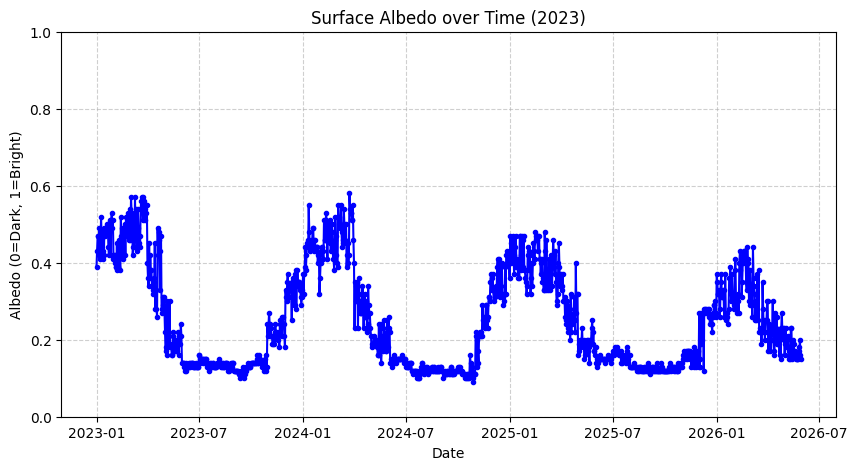

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(primary_data['Date'], primary_data['Albedo'], color='blue', marker='o', markersize=3, linestyle='-')

plt.title(f"Surface Albedo over Time ({start_date[:4]})")
plt.xlabel("Date")
plt.ylabel("Albedo (0=Dark, 1=Bright)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1) # Albedo is a percentage between 0 and 1

plt.show()

## Part IV: Comparing to a Contrasting Environment

To really understand how unique our signature pattern is, it helps to compare it to an environment that *doesn't* change much throughout the year. By default, we'll look at a desert environment (the Mojave Desert in California). Sand is relatively bright, but it doesn't melt!

In [34]:
# Give your comparison location a name
comparison_location = "Desert"

# Specify lat and long for the comparison location
contrast_lat = 35
contrast_lon = -118

Now, we'll fetch data from the comparison location and plot the albedos for both the focal and the comparison location on the same graph to compare.

Fetching data for 35, -118...


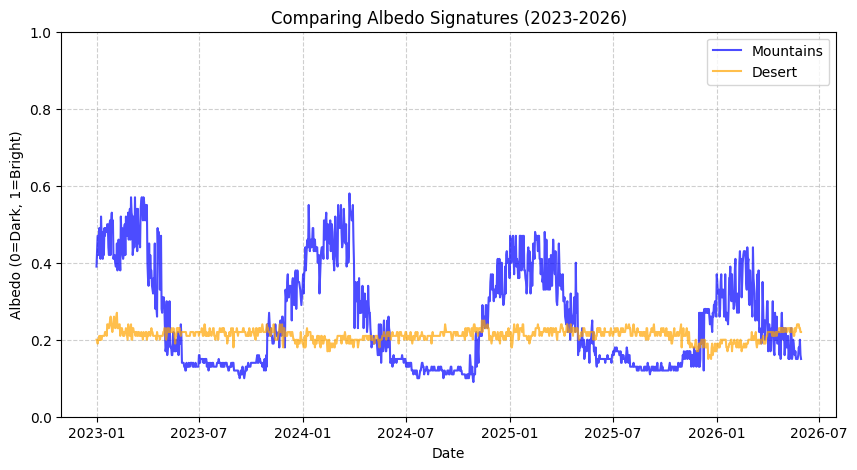

In [35]:
# Fetch the data
contrast_data = fetch_albedo_data(contrast_lat, contrast_lon, start_date, end_date)

# Plot both lines together!
plt.figure(figsize=(10, 5))

# Plot our primary location (Mountains)
plt.plot(primary_data['Date'], primary_data['Albedo'], color='blue', label=focal_location, alpha=0.7)

# Plot the contrasting location (Desert)
plt.plot(contrast_data['Date'], contrast_data['Albedo'], color='orange', label=comparison_location, alpha=0.7)

plt.title(f"Comparing Albedo Signatures ({start_date[:4]}-{end_date[:4]})")
plt.xlabel("Date")
plt.ylabel("Albedo (0=Dark, 1=Bright)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1)

plt.show()

Notice how the desert has a relatively stable, moderate albedo year-round, while the mountainous region has massive swings between summer and winter!

## Part V: Data Export

Now that we have fetched our datasets, we can save them as `.csv` files so we can open them in Excel, Google Sheets, or CODAP to do more analysis.

In [21]:
# Merge the two tables based on the Date
combined_data = pd.merge(primary_data, contrast_data, on="Date", suffixes=(focal_location, comparison_location))

# Save the combined data to a single file
combined_data.to_csv("combined_albedo.csv", index=False)

# OPTIONAL: If you are using Google Colab, uncomment the lines below to download the file to your computer.
# from google.colab import files
# files.download("combined_albedo.csv")

print("Data exported successfully!")

Data exported successfully!


## Credits

This notebook was generated with the heavy assistance of Gemini 3.1 Pro, using an extensive custom context file to communicate Rivulet style and technical standards. All text and code were carefully reviewed by a squishy human.

Data obtained from the NASA Prediction of Worldwide Energy Resources (POWER) Project, which is supported by the NASA Earth Science Data and Information System (ESDIS) Project. The data are derived from the CERES dataset.

Learn more about the NASA POWER API here: https://power.larc.nasa.gov/

This Rivulet was developed to provide real-world albedo data for a MoDa unit to be developed by Adelmo Eloy, Lucas Coletti, and Paulo Blikstein.

This notebook was developed as part of NSF Grant 2445609.